<a href="https://colab.research.google.com/github/airnandabintang-sudo/bintang-Prediksi-Kualitas-Wine/blob/main/UTS_PDAB_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [8]:
train_data = pd.read_csv('/content/data_training.csv')
test_data = pd.read_csv('/content/data_testing.csv')

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(train_data.head())
print(test_data.head())

Training data shape: (857, 13)
Testing data shape: (286, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id

In [11]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [12]:
train_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


In [13]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


#**Interpersretasi**
Dapat dilihat dari output diatas bahwa tidak ada data yang kosong (tidak ada null)

In [14]:
print("Jumlah duplicate:", train_data.duplicated().sum())

Jumlah duplicate: 0


Dapat diliat tidak ada juga duplikat data train


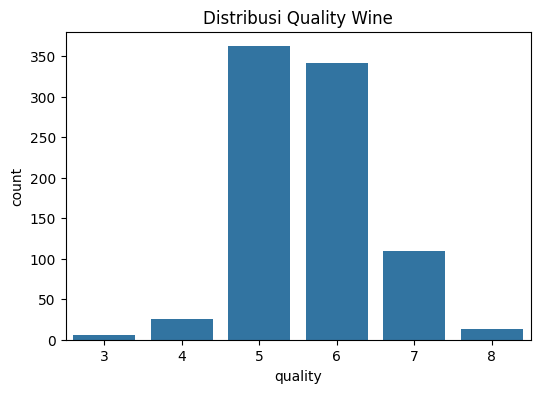

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=train_data["quality"])
plt.title("Distribusi Quality Wine")
plt.show()

# **Interpretasi**
Dominasi Kualitas Menengah (Kelas Mayoritas): Sebagian besar sampel anggur dalam dataset ini berada pada kualitas menengah. Terlihat bahwa skor kualitas 5 dan 6 mendominasi data, dengan jumlah sampel masing-masing berada di kisaran 300 hingga 350-an.

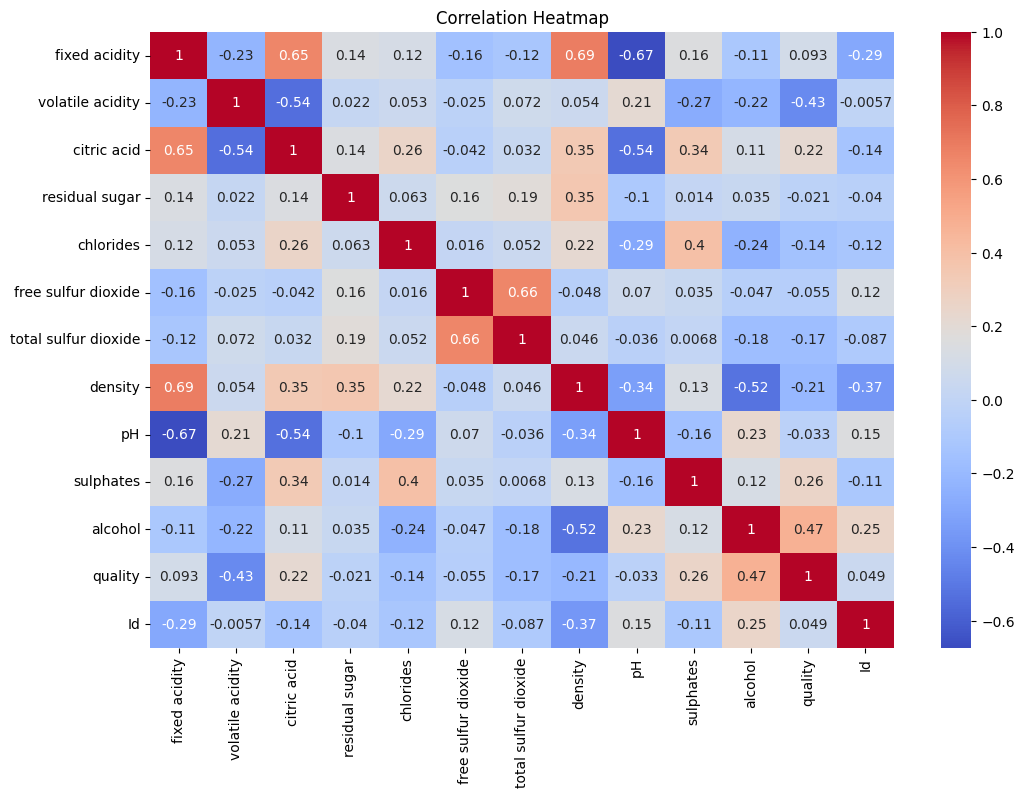

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(train_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#**Interpretasi**
Berdasarkan heatmap korelasi, fitur alcohol memiliki korelasi positif terkuat (0.47) terhadap quality, mengindikasikan bahwa anggur dengan kadar alkohol lebih tinggi cenderung dinilai lebih baik. Sebaliknya, volatile acidity memiliki korelasi negatif terkuat (-0.43), yang berarti tingginya tingkat keasaman volatil dapat menurunkan kualitas anggur. Selain itu, ditemukan korelasi tinggi secara logis antar fitur independen, seperti antara fixed acidity dan pH (-0.67) serta free sulfur dioxide dan total sulfur dioxide (0.66). Hasil analisis korelasi ini nantinya akan divalidasi lebih lanjut melalui pengujian Feature Importance pada model

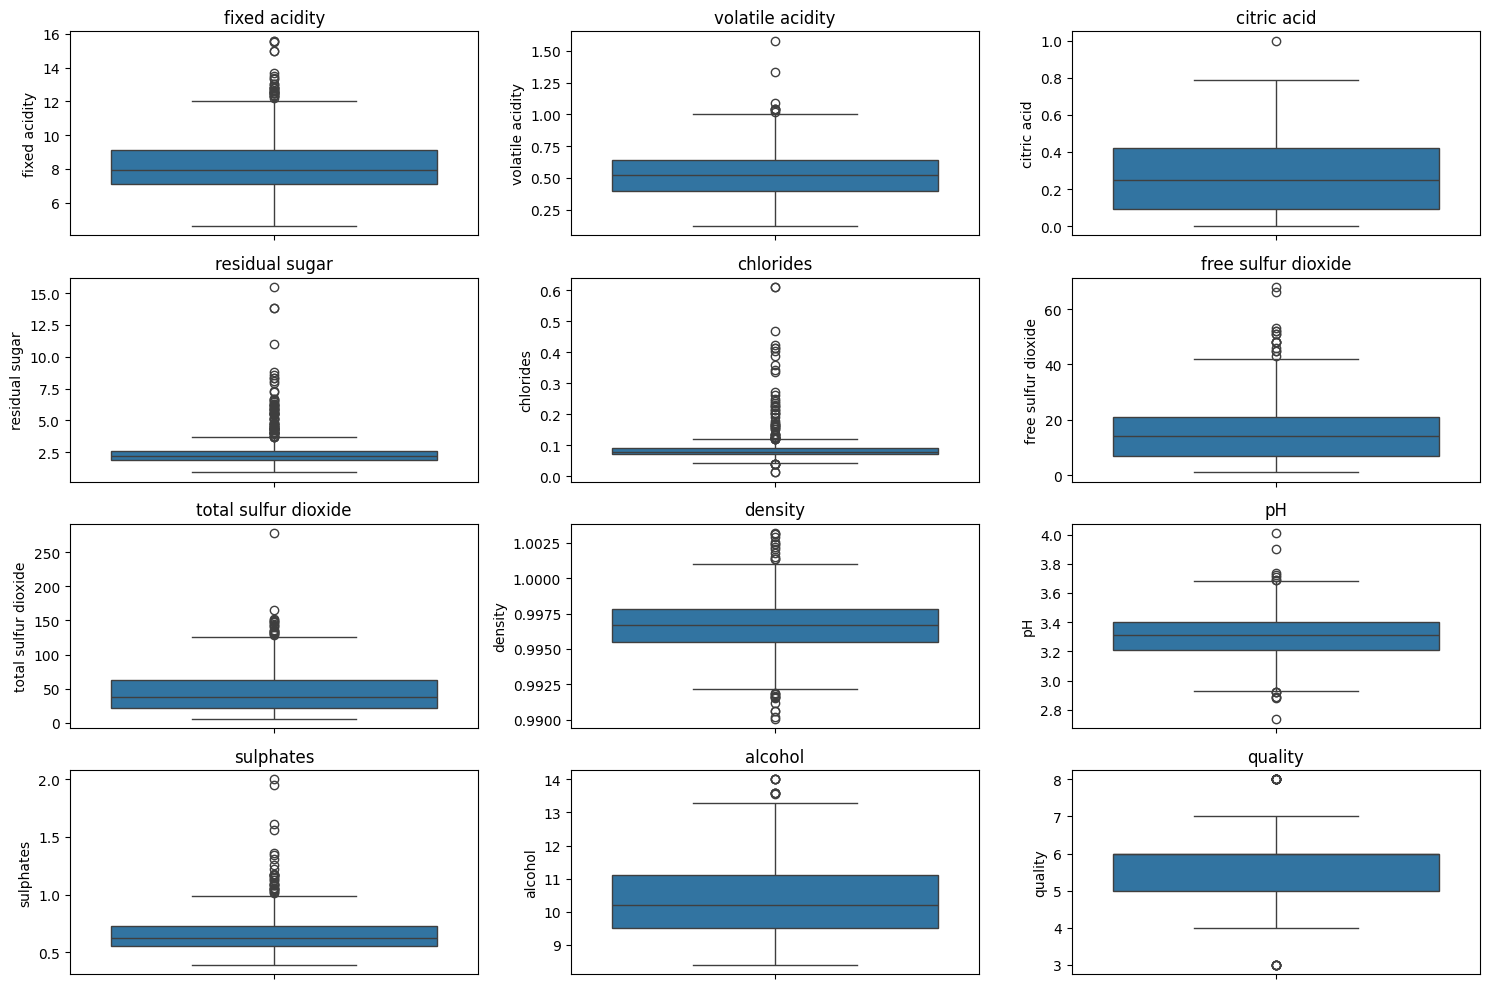

In [21]:
plt.figure(figsize=(15,10))

for i, col in enumerate(train_data.columns[:-1], 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=train_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#**Interpretasi**
Berdasarkan visualisasi boxplot untuk seluruh fitur independen, terlihat jelas bahwa sebagian besar fitur kimiawi (seperti residual sugar, chlorides, dan sulphates) memiliki jumlah outlier atau pencilan yang cukup banyak, yang ditandai dengan titik-titik di luar batas atas whiskers. Keberadaan nilai-nilai ekstrem ini menjustifikasi keputusan penggunaan algoritma berbasis pohon (tree-based) seperti Random Forest dan XGBoost dalam eksperimen pemodelan ini, karena algoritma tersebut dikenal kebal (robust) terhadap keberadaan outlier dibandingkan algoritma linier.

In [22]:
X = train_data.drop(["Id", "quality"], axis=1)
y = train_data["quality"]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0
...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5


In [23]:
y

,quality
0,5
1,5
2,7
3,6
4,6
...,...
852,4
853,5
854,6
855,6


In [26]:
X_test_data_final = test_data.drop("Id", axis=1)
test_data_id = test_data["Id"]
test_data_id

,Id
0,222
1,1514
2,417
3,754
4,516
...,...
281,1147
282,296
283,170
284,1439


In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_val:", y_val.shape)

Shape X_train: (685, 11)
Shape X_val: (172, 11)
Shape y_train: (685,)
Shape y_val: (172,)


In [28]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6104651162790697


**Interpretasi**: dapat diliat dari model random forest memiliki akurasi 0.6104

In [29]:
print(confusion_matrix(y_val, rf_pred))

[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 58 14  1  0]
 [ 0  0 25 38  5  0]
 [ 0  0  0 14  8  0]
 [ 0  0  0  0  2  1]]


In [30]:
print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.79      0.72        73
           6       0.57      0.56      0.56        68
           7       0.50      0.36      0.42        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.34      0.37       172
weighted avg       0.59      0.61      0.59       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

In [32]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [33]:
print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [34]:
best_rf = rf_grid.best_estimator_

rf_tuned_pred = best_rf.predict(X_val)

rf_tuned_acc = accuracy_score(y_val, rf_tuned_pred)

print("Tuned RF Accuracy:", rf_tuned_acc)

Tuned RF Accuracy: 0.5988372093023255


**Interpretasi**: untuk model Random Forest yang sudah di-tuning pada dataset Wine Quality mendapatkan akurasi sekitar 59.88%

In [35]:
label_map = {label:i for i,label in enumerate(sorted(y.unique()))}
reverse_map = {v:k for k,v in label_map.items()}

y_encoded = y.map(label_map)

In [36]:
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [37]:
xgb = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train2, y_train2)

xgb_pred = xgb.predict(X_val2)

xgb_acc = accuracy_score(y_val2, xgb_pred)

print("Baseline XGBoost Accuracy:", xgb_acc)

Baseline XGBoost Accuracy: 0.5697674418604651


**Interprtasi**: untuk baseline XGBoost mendapatkan akurasi 56.98%

In [38]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.1]
}

In [39]:
xgb_grid = GridSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        eval_metric='mlogloss',
        random_state=42
    ),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train2, y_train2)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [40]:
print("Best XGB Params:", xgb_grid.best_params_)

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [41]:
best_xgb = xgb_grid.best_estimator_

xgb_tuned_pred = best_xgb.predict(X_val2)

xgb_tuned_acc = accuracy_score(y_val2, xgb_tuned_pred)

print("Tuned XGBoost Accuracy:", xgb_tuned_acc)

Tuned XGBoost Accuracy: 0.5930232558139535


**Interpretasi**: untuk model XGBoost yang sudah di-tuning pada dataset Wine Quality mendapatkan akurasi sekitar 59,3%


In [42]:
rf_cv = cross_val_score(best_rf, X, y, cv=5)
print("RF CV Mean:", rf_cv.mean())

RF CV Mean: 0.642907656738746


In [43]:
xgb_cv = cross_val_score(best_xgb, X, y_encoded, cv=5)
print("XGB CV Mean:", xgb_cv.mean())

XGB CV Mean: 0.618421052631579


In [44]:
print("RF Baseline:", rf_acc)
print("RF Tuned:", rf_tuned_acc)
print("XGB Baseline:", xgb_acc)
print("XGB Tuned:", xgb_tuned_acc)

RF Baseline: 0.6104651162790697
RF Tuned: 0.5988372093023255
XGB Baseline: 0.5697674418604651
XGB Tuned: 0.5930232558139535


#**Interpretasi**
Berdasarkan pengujian, model Random Forest Baseline (tanpa tuning) menghasilkan akurasi tertinggi sebesar 61.05%. Penurunan akurasi pada RF setelah tuning (59.88%) menunjukkan bahwa parameter bawaan sudah sangat optimal untuk dataset ini. Sebaliknya, tuning pada XGBoost berhasil menaikkan akurasi (dari 56.98% ke 59.30%) dengan mengurangi overfitting. Dengan demikian, Random Forest Baseline ditetapkan sebagai model final untuk memprediksi

In [45]:
if xgb_tuned_acc > rf_tuned_acc:
    best_model = best_xgb
    model_name = "XGBoost"
else:
    best_model = best_rf
    model_name = "Random Forest"

print("Model terbaik:", model_name)

Model terbaik: Random Forest


In [46]:
best_model.fit(X, y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [47]:
pred_test = best_model.predict(X_test_final)

In [50]:
submission = pd.DataFrame({
    "Id": test_data_id,
    "quality": pred_test
})

output_filename = "hasilprediksi_003.csv"
submission.to_csv(output_filename, index=False)

from google.colab import files
files.download(output_filename)
print('File sedang diunduh')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File sedang diunduh


download file csv